In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from IPython.display import display
from matplotlib import patches as mpatches

from skarf import set_cache_dir
from skarf.covariance import load_spi_config_map
from arfcexp.skarf_utils import AVAILABLE_SKARF_FUNCS

In [2]:
project_root = Path(os.environ["PROJECT_ROOT"]).resolve()
result_root = project_root / "results/hcp_1200_homotopic_fc_parallel"

PARC_SIZE = 200
REDUCER = "mean"
USE_ABS = True
INCLUDE_SKARF_LAG1 = True
N_SUBJECTS = None
MAX_COMBOS = None
PERM_TEST = True
SEED_FILTER = None  # None -> accept any per-estimator seed within the requested run family.
N_PERM = 200
PYSPI_FUNCS = None  # None -> load every discovered PySPI estimator in the run family.
SKARF_FUNCS = None  # None -> load every discovered skarf estimator in the run family.

run_dirs = []

if not result_root.exists():
    raise FileNotFoundError(f"Result root not found: {result_root}")


def _perm_flag_from_name(path):
    if "__perm-1__" in path.name:
        return 1
    if "__perm-0__" in path.name:
        return 0
    return None


def _sub_tag(n_subjects):
    return f"subs-{n_subjects}" if n_subjects is not None else "subs-all"


def _combo_tag(max_combos):
    return f"max-{max_combos}" if max_combos is not None else "max-all"


REQUESTED_PERM_FLAG = int(bool(PERM_TEST))
SKARF_LAGS = [0, 1] if INCLUDE_SKARF_LAG1 else [0]
RUN_FAMILY_PREFIX = (
    f"parc-{PARC_SIZE}__reducer-{REDUCER}"
    f"__rankabs-{int(USE_ABS)}"
    f"__skarf-lag1-{int(INCLUDE_SKARF_LAG1)}"
    f"__{_sub_tag(N_SUBJECTS)}__{_combo_tag(MAX_COMBOS)}"
    f"__perm-{REQUESTED_PERM_FLAG}"
)
RUN_DIR_GLOB = (
    f"{RUN_FAMILY_PREFIX}"
    f"__seed-{SEED_FILTER if SEED_FILTER is not None else '*'}__nperm-{N_PERM}"
    "__selector-*"
)


def _parse_run_dir(path):
    name = path.name
    if "__selector-" not in name or "__lag-" not in name:
        return None

    selector_part = name.split("__selector-", 1)[1]
    selector_prefix, lag_text = selector_part.rsplit("__lag-", 1)
    if "__" not in selector_prefix:
        return None
    method, func = selector_prefix.split("__", 1)

    seed_text = name.split("__seed-", 1)[1].split("__", 1)[0]

    try:
        lag = int(lag_text)
    except ValueError:
        return None

    try:
        seed = int(seed_text)
    except ValueError:
        seed = None

    return {
        "method": method,
        "func": func,
        "lag": lag,
        "seed": seed,
        "run_dir": path,
        "run_perm_test": _perm_flag_from_name(path),
    }


def _spec_requested(spec):
    if spec["method"] == "pyspi":
        return PYSPI_FUNCS is None or spec["func"] in PYSPI_FUNCS
    if spec["method"] == "skarf":
        if spec["lag"] not in SKARF_LAGS:
            return False
        return SKARF_FUNCS is None or spec["func"] in SKARF_FUNCS
    return False


def _expected_specs():
    expected = []
    if PYSPI_FUNCS is not None:
        expected.extend({"method": "pyspi", "func": func, "lag": 0} for func in PYSPI_FUNCS)
    if SKARF_FUNCS is not None:
        expected.extend(
            {"method": "skarf", "func": func, "lag": lag}
            for func in SKARF_FUNCS
            for lag in SKARF_LAGS
        )
    return expected


def _spec_sort_key(spec):
    return (spec["method"], spec["func"], spec["lag"])


def _run_choice_key(spec):
    return (
        spec["run_dir"].stat().st_mtime,
        spec["seed"] is not None,
        spec["seed"] if spec["seed"] is not None else -1,
        spec["run_dir"].name,
    )

In [3]:
discovered_specs = []
for path in sorted(result_root.glob(RUN_DIR_GLOB)):
    if not path.is_dir():
        continue
    spec = _parse_run_dir(path)
    if spec is not None and _spec_requested(spec):
        discovered_specs.append(spec)

if not discovered_specs:
    raise FileNotFoundError(
        "No estimator result directories matched the requested run family. "
        f"Checked glob: {RUN_DIR_GLOB}"
    )

run_spec_map = {}
duplicate_rows = []
for spec in discovered_specs:
    key = (spec["method"], spec["func"], spec["lag"])
    current = run_spec_map.get(key)
    if current is None:
        run_spec_map[key] = spec
        continue

    if _run_choice_key(spec) >= _run_choice_key(current):
        kept = spec
        dropped = current
    else:
        kept = current
        dropped = spec

    run_spec_map[key] = kept
    duplicate_rows.append({
        "method": spec["method"],
        "func": spec["func"],
        "lag": spec["lag"],
        "kept_run_dir": kept["run_dir"].name,
        "dropped_run_dir": dropped["run_dir"].name,
    })

run_specs = sorted(run_spec_map.values(), key=_spec_sort_key)
run_dirs = [spec["run_dir"] for spec in run_specs]
selected_perm_flags = sorted({
    spec["run_perm_test"] for spec in run_specs if spec["run_perm_test"] is not None
})
duplicate_specs_df = pd.DataFrame(duplicate_rows)

expected_specs = _expected_specs()
found_keys = {(spec["method"], spec["func"], spec["lag"]) for spec in run_specs}
missing_rows = [
    {
        **spec,
        "requested_perm_test": REQUESTED_PERM_FLAG,
        "seed_filter": SEED_FILTER,
        "selected_seed": None,
        "run_dir": None,
        "status": "missing",
    }
    for spec in expected_specs
    if (spec["method"], spec["func"], spec["lag"]) not in found_keys
]

load_status_rows = [
    {
        "method": spec["method"],
        "func": spec["func"],
        "lag": spec["lag"],
        "requested_perm_test": REQUESTED_PERM_FLAG,
        "seed_filter": SEED_FILTER,
        "selected_seed": spec["seed"],
        "run_dir": spec["run_dir"].name,
        "status": "loaded",
    }
    for spec in run_specs
]
load_status_rows.extend(missing_rows)
load_status_df = pd.DataFrame(load_status_rows).sort_values(["method", "func", "lag", "status"]).reset_index(drop=True)
missing_specs_df = load_status_df.loc[load_status_df["status"] == "missing"].reset_index(drop=True)

print("Result root:", result_root)
print("Requested run family:", RUN_FAMILY_PREFIX)
print("Seed filter:", SEED_FILTER if SEED_FILTER is not None else "any matching seed")
print("Discovered family directories:", len(discovered_specs))
print("Loaded estimator directories:", len(run_specs))
print("Duplicate estimator directories collapsed:", len(duplicate_specs_df))
print("Selected perm flags:", selected_perm_flags if selected_perm_flags else ["unknown"])
print("Example directory:", run_dirs[0])
if len(missing_specs_df) > 0:
    print("Missing estimator directories:", len(missing_specs_df))
    display(missing_specs_df.head(20))
if len(duplicate_specs_df) > 0:
    print("Duplicate estimator directories detected:", len(duplicate_specs_df))
    display(duplicate_specs_df.head(20))

Result root: /home/aerkent/skarf-experiments/results/hcp_1200_homotopic_fc_parallel
Requested run family: parc-200__reducer-mean__rankabs-1__skarf-lag1-1__subs-all__max-all__perm-1
Seed filter: any matching seed
Discovered family directories: 171
Loaded estimator directories: 171
Duplicate estimator directories collapsed: 0
Selected perm flags: [1]
Example directory: /home/aerkent/skarf-experiments/results/hcp_1200_homotopic_fc_parallel/parc-200__reducer-mean__rankabs-1__skarf-lag1-1__subs-all__max-all__perm-1__seed-2173__nperm-200__selector-pyspi__bary_euclidean_max__lag-0


In [4]:
def _safe_read_csv(path):
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return None


combo_frames = []
excluded_frames = []
method_summary_frames = []
scores_frames = []

for spec in run_specs:
    run_dir = spec["run_dir"]
    combo_path = run_dir / "combination_status.csv"
    excluded_path = run_dir / "excluded_combinations.csv"
    method_summary_path = run_dir / "method_homotopic_summary.csv"
    scores_path = run_dir / "subject_homotopic_scores.parquet"
    run_perm_test = spec["run_perm_test"]

    df = _safe_read_csv(combo_path)
    if df is not None:
        df["run_dir"] = run_dir.name
        df["run_perm_test"] = run_perm_test
        combo_frames.append(df)

    df = _safe_read_csv(excluded_path)
    if df is not None:
        df["run_dir"] = run_dir.name
        df["run_perm_test"] = run_perm_test
        excluded_frames.append(df)

    df = _safe_read_csv(method_summary_path)
    if df is not None:
        df["run_dir"] = run_dir.name
        df["run_perm_test"] = run_perm_test
        method_summary_frames.append(df)

    if scores_path.exists():
        df = pd.read_parquet(scores_path)
        if len(df) > 0:
            df["run_dir"] = run_dir.name
            df["run_perm_test"] = run_perm_test
            scores_frames.append(df)

combo_df = pd.concat(combo_frames, ignore_index=True) if combo_frames else pd.DataFrame()
excluded_df = pd.concat(excluded_frames, ignore_index=True) if excluded_frames else pd.DataFrame()
method_summary_df = pd.concat(method_summary_frames, ignore_index=True) if method_summary_frames else pd.DataFrame()
scores_df = pd.concat(scores_frames, ignore_index=True) if scores_frames else pd.DataFrame()

if len(combo_df) > 0 and "combo_key" in combo_df.columns:
    combo_df = combo_df.drop_duplicates(subset=["combo_key"], keep="last").reset_index(drop=True)
if len(method_summary_df) > 0 and "combo_key" in method_summary_df.columns:
    method_summary_df = method_summary_df.drop_duplicates(subset=["combo_key"], keep="last").reset_index(drop=True)
if len(scores_df) > 0 and {"sub", "combo_key"}.issubset(scores_df.columns):
    scores_df = scores_df.drop_duplicates(subset=["sub", "combo_key"], keep="last").reset_index(drop=True)
if len(excluded_df) > 0 and {"method", "func"}.issubset(excluded_df.columns):
    excluded_df = excluded_df.drop_duplicates(subset=["method", "func", "reason"], keep="last").reset_index(drop=True)

null_summary_cols = ["heterotopic_null_q25", "heterotopic_null_q75"]
null_data_available = (
    len(scores_df) > 0
    and set(null_summary_cols).issubset(scores_df.columns)
    and all(np.isfinite(scores_df[col].to_numpy(dtype=np.float64)).any() for col in null_summary_cols)
)
print("Populated null summaries available:", bool(null_data_available))

if len(scores_df) > 0:
    family_subject_df = (
        scores_df.dropna(subset=["homotopic_score"])
        .groupby(["sub", "method"], as_index=False)["homotopic_score"]
        .mean()
        .rename(columns={"homotopic_score": "family_mean_score"})
    )
else:
    family_subject_df = pd.DataFrame(columns=["sub", "method", "family_mean_score"])

combo_df.head()

Populated null summaries available: True


,method,func,lag,combo_key,status,valid_fraction,n_subjects,n_valid_subjects,run_dir,run_perm_test
0,pyspi,bary_euclidean_max,0,pyspi__bary_euclidean_max,ok,1.0,867,867,parc-200__reducer-mean__rankabs-1__skarf-lag1-...,1
1,pyspi,ce_gaussian,0,pyspi__ce_gaussian,ok,1.0,867,867,parc-200__reducer-mean__rankabs-1__skarf-lag1-...,1
2,pyspi,ce_kernel_W-0.5,0,pyspi__ce_kernel_W-0.5,ok,1.0,867,867,parc-200__reducer-mean__rankabs-1__skarf-lag1-...,1
3,pyspi,cohmag_multitaper_max_fs-1_fmin-0-25_fmax-0-5,0,pyspi__cohmag_multitaper_max_fs-1_fmin-0-25_fm...,ok,1.0,867,867,parc-200__reducer-mean__rankabs-1__skarf-lag1-...,1
4,pyspi,cohmag_multitaper_max_fs-1_fmin-0_fmax-0-25,0,pyspi__cohmag_multitaper_max_fs-1_fmin-0_fmax-...,ok,1.0,867,867,parc-200__reducer-mean__rankabs-1__skarf-lag1-...,1


In [5]:
print("Requested run family:", RUN_FAMILY_PREFIX)
print("Seed filter:", SEED_FILTER if SEED_FILTER is not None else "any matching seed")
print("Discovered family directories:", len(discovered_specs))
print("Loaded estimator directories:", int((load_status_df["status"] == "loaded").sum()))
print("Missing estimator directories:", int((load_status_df["status"] == "missing").sum()))
print("Duplicate estimator directories collapsed:", len(duplicate_specs_df))

if len(missing_specs_df) > 0:
    print("Missing estimator directory examples:")
    display(missing_specs_df.head(20))
if len(duplicate_specs_df) > 0:
    print("Duplicate estimator directory examples:")
    display(duplicate_specs_df.head(20))

print("Total combinations evaluated:", len(combo_df))
if "status" in combo_df.columns:
    print("Combinations with sufficient data:", int((combo_df["status"] == "ok").sum()))
else:
    print("Combinations with sufficient data: unavailable (missing status column)")

print("Excluded combinations:", len(excluded_df))
print("Excluded reasons:")
if len(excluded_df) > 0 and "reason" in excluded_df.columns:
    print(excluded_df["reason"].value_counts(dropna=False))
else:
    print("None")

display(load_status_df.groupby(["method", "status"]).size().rename("n").reset_index())

if len(combo_df) > 0 and {"method", "status"}.issubset(combo_df.columns):
    display(combo_df.groupby(["method", "status"]).size().rename("n").reset_index())

Requested run family: parc-200__reducer-mean__rankabs-1__skarf-lag1-1__subs-all__max-all__perm-1
Seed filter: any matching seed
Discovered family directories: 171
Loaded estimator directories: 171
Missing estimator directories: 0
Duplicate estimator directories collapsed: 0
Total combinations evaluated: 171
Combinations with sufficient data: 170
Excluded combinations: 2
Excluded reasons:
reason
degenerate_matrix    2
Name: count, dtype: int64


,method,status,n
0,pyspi,loaded,147
1,skarf,loaded,24


,method,status,n
0,pyspi,insufficient_data,1
1,pyspi,ok,146
2,skarf,ok,24


In [6]:
def _cohen_d_paired(x, y):
    diff = np.asarray(x, dtype=np.float64) - np.asarray(y, dtype=np.float64)
    sd = np.std(diff, ddof=1)
    if not np.isfinite(sd) or sd <= 0:
        return np.nan
    return float(np.mean(diff) / sd)


def _cohen_d_independent(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)
    pooled = ((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2)
    if not np.isfinite(pooled) or pooled <= 0:
        return np.nan
    return float((np.mean(x) - np.mean(y)) / np.sqrt(pooled))


def _cliffs_delta(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    cmp = np.subtract.outer(x, y)
    n_pos = int(np.sum(cmp > 0))
    n_neg = int(np.sum(cmp < 0))
    return float((n_pos - n_neg) / (len(x) * len(y)))


stats_summary = {
    "family_subject_test": None,
    "method_distribution_test": None,
    "skarf_lag_test": None,
}

if len(family_subject_df) > 0:
    pivot = family_subject_df.pivot(index="sub", columns="method", values="family_mean_score")
    if {"pyspi", "skarf"}.issubset(set(pivot.columns)):
        paired = pivot[["pyspi", "skarf"]].dropna()
        if len(paired) > 0:
            py = paired["pyspi"].to_numpy(dtype=np.float64)
            sk = paired["skarf"].to_numpy(dtype=np.float64)
            test = stats.wilcoxon(py, sk, alternative="two-sided")
            stats_summary["family_subject_test"] = {
                "n": int(len(paired)),
                "wilcoxon_stat": float(test.statistic),
                "pvalue": float(test.pvalue),
                "mean_pyspi": float(np.mean(py)),
                "mean_skarf": float(np.mean(sk)),
                "mean_diff_pyspi_minus_skarf": float(np.mean(py - sk)),
                "cohen_dz": float(_cohen_d_paired(py, sk)),
            }

if len(method_summary_df) > 0:
    py = method_summary_df.loc[method_summary_df["method"] == "pyspi", "mean"].dropna().to_numpy(dtype=np.float64)
    sk = method_summary_df.loc[method_summary_df["method"] == "skarf", "mean"].dropna().to_numpy(dtype=np.float64)
    if len(py) > 0 and len(sk) > 0:
        test = stats.mannwhitneyu(py, sk, alternative="two-sided")
        stats_summary["method_distribution_test"] = {
            "n_pyspi": int(len(py)),
            "n_skarf": int(len(sk)),
            "mannwhitney_u": float(test.statistic),
            "pvalue": float(test.pvalue),
            "mean_pyspi": float(np.mean(py)),
            "mean_skarf": float(np.mean(sk)),
            "cohen_d": float(_cohen_d_independent(py, sk)),
            "cliffs_delta": float(_cliffs_delta(py, sk)),
        }

    skarf_summary_df = method_summary_df.query("method == 'skarf'").copy()
    if len(skarf_summary_df) > 0:
        lag_pivot = skarf_summary_df.pivot(index="func", columns="lag", values="mean")
        if {0, 1}.issubset(set(lag_pivot.columns)):
            lag_pairs = lag_pivot[[0, 1]].dropna()
            if len(lag_pairs) > 0:
                lag0 = lag_pairs[0].to_numpy(dtype=np.float64)
                lag1 = lag_pairs[1].to_numpy(dtype=np.float64)
                test = stats.wilcoxon(lag0, lag1, alternative="two-sided")
                stats_summary["skarf_lag_test"] = {
                    "n": int(len(lag_pairs)),
                    "wilcoxon_stat": float(test.statistic),
                    "pvalue": float(test.pvalue),
                    "mean_lag0": float(np.mean(lag0)),
                    "mean_lag1": float(np.mean(lag1)),
                    "cohen_dz": float(_cohen_d_paired(lag0, lag1)),
                }

stats_summary

{'family_subject_test': {'n': 867,
  'wilcoxon_stat': 0.0,
  'pvalue': 1.6339286643398067e-143,
  'mean_pyspi': 0.5039256829219245,
  'mean_skarf': 0.5527720073357085,
  'mean_diff_pyspi_minus_skarf': -0.04884632441378395,
  'cohen_dz': -4.662943513022687},
 'method_distribution_test': {'n_pyspi': 146,
  'n_skarf': 24,
  'mannwhitney_u': 944.0,
  'pvalue': 0.0003018413505585579,
  'mean_pyspi': 0.5039256829219245,
  'mean_skarf': 0.5527720073357085,
  'cohen_d': -0.6006521176168792,
  'cliffs_delta': -0.4611872146118721},
 'skarf_lag_test': {'n': 12,
  'wilcoxon_stat': 18.0,
  'pvalue': 0.10986328125,
  'mean_lag0': 0.5499562153012371,
  'mean_lag1': 0.55558779937018,
  'cohen_dz': -0.5693397700435061}}

,n,wilcoxon_stat,pvalue,mean_pyspi,mean_skarf,mean_diff_pyspi_minus_skarf,cohen_dz
0,867,0.0,1.633929e-143,0.503926,0.552772,-0.048846,-4.662944


Paired subjects: 867


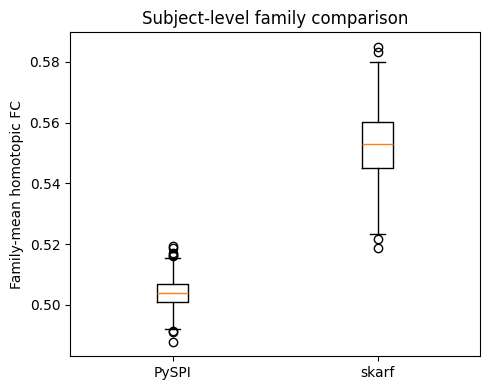

In [7]:
pivot = family_subject_df.pivot(index='sub', columns='method', values='family_mean_score')
required = {'pyspi', 'skarf'}

display(pd.DataFrame(stats_summary.get('family_subject_test') or {}, index=[0]))

if required.issubset(set(pivot.columns)):
    paired = pivot[['pyspi', 'skarf']].dropna()
    print('Paired subjects:', len(paired))

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.boxplot([paired['pyspi'], paired['skarf']], tick_labels=['PySPI', 'skarf'])
    ax.set_ylabel('Family-mean homotopic FC')
    ax.set_title('Subject-level family comparison')
    plt.tight_layout()
else:
    print('Family comparison plot skipped: both PySPI and skarf are required.')
    print('Available method columns:', sorted(map(str, pivot.columns)))

,n_pyspi,n_skarf,mannwhitney_u,pvalue,mean_pyspi,mean_skarf,cohen_d,cliffs_delta
0,146,24,944.0,0.000302,0.503926,0.552772,-0.600652,-0.461187


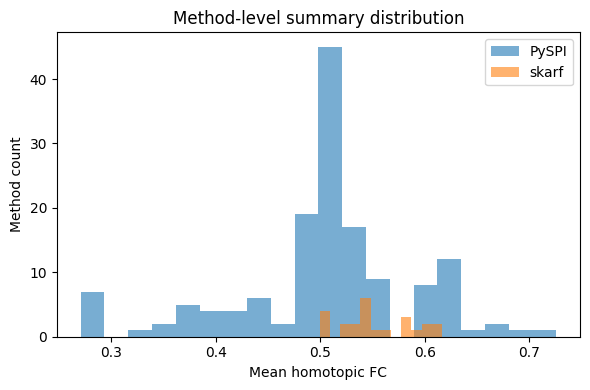

In [8]:
display(pd.DataFrame(stats_summary.get('method_distribution_test', {}), index=[0]))

fig, ax = plt.subplots(figsize=(6, 4))
py = method_summary_df.loc[method_summary_df['method'] == 'pyspi', 'mean'].dropna()
sk = method_summary_df.loc[method_summary_df['method'] == 'skarf', 'mean'].dropna()
ax.hist(py, bins=20, alpha=0.6, label='PySPI')
ax.hist(sk, bins=12, alpha=0.6, label='skarf')
ax.set_xlabel('Mean homotopic FC')
ax.set_ylabel('Method count')
ax.legend()
ax.set_title('Method-level summary distribution')
plt.tight_layout()

,n,wilcoxon_stat,pvalue,mean_lag0,mean_lag1,cohen_dz
0,12,18.0,0.109863,0.549956,0.555588,-0.56934


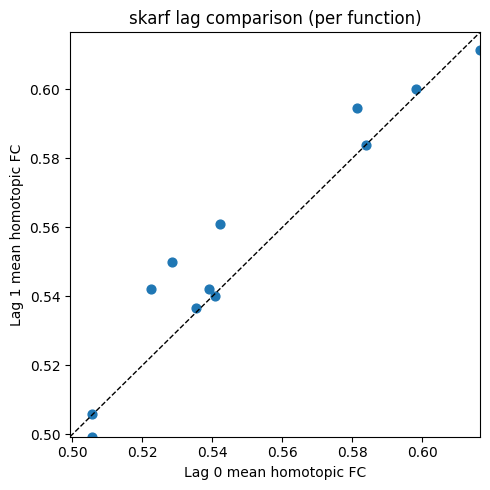

In [9]:
display(pd.DataFrame(stats_summary.get('skarf_lag_test') or {}, index=[0]))

skarf = method_summary_df.query("method == 'skarf'").copy()
lag_pivot = skarf.pivot(index='func', columns='lag', values='mean')

if {0, 1}.issubset(set(lag_pivot.columns)):
    lag_pivot = lag_pivot[[0, 1]].dropna()
    if len(lag_pivot) == 0:
        print('No skarf functions have both lag-0 and lag-1 summaries.')
    else:
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(lag_pivot[0], lag_pivot[1], s=40)
        lims = [
            min(lag_pivot[0].min(), lag_pivot[1].min()),
            max(lag_pivot[0].max(), lag_pivot[1].max()),
        ]
        ax.plot(lims, lims, '--', color='k', linewidth=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel('Lag 0 mean homotopic FC')
        ax.set_ylabel('Lag 1 mean homotopic FC')
        ax.set_title('skarf lag comparison (per function)')
        plt.tight_layout()
else:
    print('Lag scatter skipped: both lag-0 and lag-1 columns are required.')
    print('Available lag columns:', sorted(map(str, lag_pivot.columns)))

In [10]:
top_py = method_summary_df.query("method == 'pyspi'").nlargest(10, 'mean')[['func', 'lag', 'mean', 'median']]
top_sk = method_summary_df.query("method == 'skarf'").nlargest(10, 'mean')[['func', 'lag', 'mean', 'median']]

print('Top 10 PySPI methods by mean homotopic FC')
display(top_py)

print('Top 10 skarf methods by mean homotopic FC')
display(top_sk)

Top 10 PySPI methods by mean homotopic FC


,func,lag,mean,median
59,lcss_constraint-sakoe-chiba,0,0.725897,0.726894
0,bary_euclidean_max,0,0.693921,0.695088
143,xcorr_max_sig-True,0,0.677834,0.677945
58,lcss,0,0.665260,0.666236
22,cov_GraphicalLassoCV,0,0.636628,0.637477
64,mi_gaussian,0,0.621025,0.620649
26,cov_ShrunkCovariance,0,0.619610,0.619219
21,cov_EmpiricalCovariance,0,0.619610,0.619219
25,cov_OAS,0,0.619604,0.619274
23,cov_LedoitWolf,0,0.619604,0.619282


Top 10 skarf methods by mean homotopic FC


,func,lag,mean,median
148,cov_graphicallasso,0,0.616560,0.618428
149,cov_graphicallasso,1,0.611491,0.612600
147,cov_empirical,1,0.600029,0.600674
146,cov_empirical,0,0.598291,0.599140
163,linear_pls,1,0.594518,0.594711
161,linear_pca-ridge,1,0.583968,0.584425
160,linear_pca-ridge,0,0.583821,0.584456
162,linear_pls,0,0.581392,0.581300
165,linear_ridge,1,0.561111,0.561578
153,linear_enet-pos,1,0.549874,0.549138


## Poster-style Box Plots

In [11]:
PROJECT_ROOT = Path(os.environ["PROJECT_ROOT"]).resolve()
STYLE_PATH = os.environ["MPL_STYLE"]
plt.style.use(STYLE_PATH)

PLOTW, PLOTH = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

TOPK_PYSPI_PER_NARROW_CATEGORY = 2
MAX_SKARF_FUNCS = 12
LAG_ORDER = [0, 1]
LAG_STYLES = {
    0: {"alpha": 0.85, "hatch": ""},
    1: {"alpha": 0.45, "hatch": "//"},
}
PERM_NULL_BAND_COLOR = "#6c757d"
EMPIRICAL_COV_BAND_COLOR = "#d95f02"
PERM_NULL_BAND_ALPHA = 0.18
EMPIRICAL_COV_BAND_ALPHA = 0.22


def add_iqr_band(
    ax,
    q25: float,
    q75: float,
    color: str,
    alpha: float = 0.2,
    label: str | None = None,
):
    if not (np.isfinite(q25) and np.isfinite(q75)):
        return None
    span = ax.axhspan(q25, q75, color=color, alpha=alpha, zorder=0.1, linewidth=0)
    if label:
        span.set_label(label)
    return span


def add_estimator_null_band(
    ax,
    positions: np.ndarray,
    q25: np.ndarray,
    q75: np.ndarray,
    color: str,
    alpha: float,
    label: str | None = None,
):
    finite = np.isfinite(q25) & np.isfinite(q75)
    if not np.any(finite):
        return None
    band = ax.fill_between(
        positions[finite],
        q25[finite],
        q75[finite],
        color=color,
        alpha=alpha,
        zorder=0.12,
        linewidth=0,
        label=label,
    )
    return band


def get_significance(pvalue: float) -> int:
    if pvalue < 0.001:
        return 3
    if pvalue < 0.01:
        return 2
    if pvalue < 0.05:
        return 1
    return 0


def format_label(
    base_label: str,
    values: np.ndarray,
    null_p: float,
    baseline_p: float,
    bonferroni_factor: int,
    baseline_score: float,
) -> str:
    null_sig = get_significance(null_p * bonferroni_factor)
    if not null_sig:
        prefix = "(·)"
    else:
        baseline_sig = get_significance(baseline_p * bonferroni_factor)
        if baseline_sig:
            prefix = "(<)" if np.median(values) < baseline_score else "(>)"
        else:
            prefix = "(~)"
    return f"{prefix} {base_label}"


def _safe_mwu_pvalue(x: np.ndarray, y: np.ndarray, alternative: str) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return 1.0
    return float(stats.mannwhitneyu(x, y, alternative=alternative).pvalue)


required_cols = {"sub", "method", "func", "lag", "homotopic_score"}
if not required_cols.issubset(scores_df.columns):
    missing = sorted(required_cols.difference(scores_df.columns))
    raise KeyError(f"scores_df is missing required columns: {missing}")

required_null_cols = {"heterotopic_null_q25", "heterotopic_null_q75"}
if not required_null_cols.issubset(scores_df.columns):
    missing = sorted(required_null_cols.difference(scores_df.columns))
    raise KeyError(
        f"scores_df is missing per-estimator null columns: {missing}. "
        "Re-run with --perm-test."
    )
if not null_data_available:
    raise ValueError(
        "Loaded homotopic scores do not contain populated heterotopic null summaries. "
        "The notebook likely selected perm_test=False outputs; prefer __perm-1__ result directories."
    )

plot_df = scores_df.dropna(subset=["homotopic_score"]).copy()
plot_df["func"] = plot_df["func"].astype(str)
plot_df["lag"] = plot_df["lag"].fillna(0).astype(int)

if len(plot_df) == 0:
    raise ValueError("No non-null homotopic scores available for plotting.")

score_col = "homotopic_score"
score_min = float(np.nanmin(plot_df[score_col]))
score_max = float(np.nanmax(plot_df[score_col]))
print("Using ranked homotopic mean scores directly (no normalization).")
print(f"Score range: [{score_min:.3f}, {score_max:.3f}]")

if score_min < -1e-6 or score_max > 1 + 1e-6:
    raise ValueError(
        "Detected homotopic_score values outside [0, 1]. "
        "This usually means legacy absolute-scale outputs were loaded instead of rank-based outputs."
    )

emp_cov_df = plot_df.loc[
    (plot_df["method"] == "pyspi")
    & (plot_df["func"] == "cov_EmpiricalCovariance")
    & (plot_df["lag"] == 0),
    score_col,
].to_numpy(dtype=np.float64)
emp_cov_df = emp_cov_df[np.isfinite(emp_cov_df)]
if len(emp_cov_df) == 0:
    raise ValueError(
        "Empirical covariance baseline missing (expected pyspi/cov_EmpiricalCovariance lag=0 rows)."
    )
emp_cov_q25, emp_cov_q75 = np.nanpercentile(emp_cov_df, [25, 75])
emp_cov_median = float(np.nanmedian(emp_cov_df))

has_directional = {"homotopic_score_upper", "homotopic_score_lower"}.issubset(plot_df.columns)
if has_directional:
    directional_valid = (
        np.isfinite(plot_df["homotopic_score_upper"]).any()
        and np.isfinite(plot_df["homotopic_score_lower"]).any()
    )
    if directional_valid:
        directional_summary = (
            plot_df.groupby(["method", "func", "lag"], as_index=False)[
                ["homotopic_score_upper", "homotopic_score_lower"]
            ]
            .median()
            .sort_values(["method", "func", "lag"])
        )
        print("Directional median summaries are available.")
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(directional_summary[directional_summary["homotopic_score_lower"].notna()])

Using ranked homotopic mean scores directly (no normalization).
Score range: [0.220, 0.777]
Directional median summaries are available.


,method,func,lag,homotopic_score_upper,homotopic_score_lower
2,pyspi,ce_kernel_W-0.5,0,0.389696,0.391565
43,pyspi,gc_gaussian_k-1_kt-1_l-1_lt-1,0,0.517884,0.512604
44,pyspi,gd_multitaper_delay_fs-1_fmin-0-25_fmax-0-5,0,0.491814,0.491814
45,pyspi,gd_multitaper_delay_fs-1_fmin-0_fmax-0-25,0,0.437115,0.437115
46,pyspi,gd_multitaper_delay_fs-1_fmin-0_fmax-0-5,0,0.518539,0.518539
78,pyspi,phase_multitaper_max_fs-1_fmin-0-25_fmax-0-5,0,0.401407,0.399592
79,pyspi,phase_multitaper_max_fs-1_fmin-0_fmax-0-25,0,0.324631,0.324626
80,pyspi,phase_multitaper_max_fs-1_fmin-0_fmax-0-5,0,0.338256,0.340020
81,pyspi,phase_multitaper_mean_fs-1_fmin-0-25_fmax-0-5,0,0.454418,0.454418
82,pyspi,phase_multitaper_mean_fs-1_fmin-0_fmax-0-25,0,0.431897,0.429949


In [12]:
pyspi_df = plot_df.query("method == 'pyspi'").copy()
spi_list_dir = PROJECT_ROOT / "resources/spi_lists"
set_cache_dir(spi_list_dir)
spi_config_map, _ = load_spi_config_map()
spi_list = (spi_list_dir / "spi_list_select_300s_149.txt").read_text().strip().split()
spi_id_map = {spi: idx for idx, spi in enumerate(spi_list, start=1)}

spi_table = pd.DataFrame.from_records(
    [
        {
            "spi": spi,
            "category": config["module_name"].split(".")[-1],
            "identifier": spi.split("_")[0],
        }
        for spi, config in spi_config_map.items()
        if spi in spi_list
    ]
)
spi_table["spi"] = pd.Categorical(spi_table["spi"], categories=spi_list, ordered=True)
category_levels = sorted(spi_table["category"].unique())
spi_table["category"] = pd.Categorical(spi_table["category"], categories=category_levels, ordered=True)
identifier_levels = [identifier for identifier in spi_table["identifier"].unique()]
spi_table["identifier"] = pd.Categorical(spi_table["identifier"], categories=identifier_levels, ordered=True)

pyspi_category_colors = {
    category: color_cycle[ii % len(color_cycle)]
    for ii, category in enumerate(category_levels)
}

pyspi_with_meta = spi_table.merge(
    pyspi_df.rename(columns={"func": "spi"}),
    on="spi",
    how="right",
)
pyspi_with_meta = pyspi_with_meta.dropna(subset=["spi"])
pyspi_with_meta["category"] = pd.Categorical(
    pyspi_with_meta["category"],
    categories=category_levels,
    ordered=True,
)
pyspi_with_meta["identifier"] = pd.Categorical(
    pyspi_with_meta["identifier"],
    categories=identifier_levels,
    ordered=True,
)

pyspi_values = (
    pyspi_with_meta.groupby(["category", "identifier", "spi"], as_index=False, observed=True)[score_col]
    .apply(lambda vals: vals.to_numpy(dtype=np.float64))
    .rename(columns={score_col: "values"})
)
pyspi_values["values"] = pyspi_values["values"].apply(lambda arr: arr[np.isfinite(arr)])
pyspi_values["median_score"] = pyspi_values["values"].apply(
    lambda arr: np.median(arr) if len(arr) else np.nan
)
pyspi_values = pyspi_values.sort_values(
    ["category", "identifier", "median_score"],
    ascending=[True, True, False],
)

pyspi_top_df = (
    pyspi_values.groupby(["category", "identifier"], as_index=False, group_keys=False, observed=True)
    .head(TOPK_PYSPI_PER_NARROW_CATEGORY)
    .reset_index(drop=True)
)
pyspi_funcs = pyspi_top_df["spi"].tolist()
pyspi_categories = [category for category in category_levels if category in set(pyspi_top_df["category"])]
pyspi_func_to_category = dict(zip(pyspi_top_df["spi"], pyspi_top_df["category"]))

pyspi_null_df = (
    pyspi_with_meta.groupby("spi", as_index=False)[["heterotopic_null_q25", "heterotopic_null_q75"]]
    .median()
    .set_index("spi")
)

if "heterotopic_null_mean" in pyspi_with_meta.columns:
    pyspi_null_ref_df = (
        pyspi_with_meta.groupby("spi", as_index=False)["heterotopic_null_mean"]
        .median()
        .set_index("spi")
    )
else:
    pyspi_null_ref_df = pd.DataFrame(
        {"heterotopic_null_mean": (pyspi_null_df["heterotopic_null_q25"] + pyspi_null_df["heterotopic_null_q75"]) / 2.0}
    )

pyspi_test_count = max(len(pyspi_funcs), 1)
pyspi_signif_labels = {}
for spi in pyspi_funcs:
    vals = pyspi_with_meta.loc[pyspi_with_meta["spi"] == spi, score_col].to_numpy(dtype=np.float64)
    null_vals = (
        pyspi_with_meta.loc[pyspi_with_meta["spi"] == spi, "heterotopic_null_mean"].to_numpy(dtype=np.float64)
        if "heterotopic_null_mean" in pyspi_with_meta.columns
        else np.array([], dtype=np.float64)
    )
    if len(null_vals) == 0 and spi in pyspi_null_ref_df.index:
        null_vals = np.array([float(pyspi_null_ref_df.loc[spi, "heterotopic_null_mean"])], dtype=np.float64)
    null_p = _safe_mwu_pvalue(vals, null_vals, alternative="greater")
    baseline_p = _safe_mwu_pvalue(vals, emp_cov_df, alternative="two-sided")
    base_label = f"{spi_id_map.get(spi, 0):03d} {spi[:20]}"
    pyspi_signif_labels[spi] = format_label(
        base_label,
        vals[np.isfinite(vals)],
        null_p,
        baseline_p,
        pyspi_test_count,
        emp_cov_median,
    )

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(pyspi_top_df)

,category,identifier,spi,values,median_score
0,basic,cov,cov_GraphicalLassoCV,"[0.6535686826302168, 0.6086931832458101, 0.647...",0.637477
1,basic,cov,cov_LedoitWolf,"[0.6302324178999472, 0.5976265735319984, 0.635...",0.619282
2,basic,prec,prec_GraphicalLassoCV,"[0.5827523304605644, 0.5756466242870423, 0.553...",0.555847
3,basic,prec,prec_ShrunkCovariance,"[0.5326822281966883, 0.58034774743084, 0.52790...",0.539355
4,basic,spearmanr,spearmanr,"[0.6235156662227694, 0.5970202768913792, 0.632...",0.617508
5,basic,kendalltau,kendalltau,"[0.6240438201964874, 0.5976368752983743, 0.631...",0.617796
6,basic,xcorr,xcorr_max_sig-True,"[0.7317043141787483, 0.6620482926706701, 0.709...",0.677945
7,basic,xcorr,xcorr_mean_sig-True,"[0.6132568657503958, 0.6223106108193673, 0.636...",0.602819
8,causal,reci,reci,"[0.3942784366441368, 0.4328741928189151, 0.415...",0.424556
9,distance,pdist,pdist_chebyshev,"[0.23597879343702105, 0.2826191612854594, 0.24...",0.289781


In [13]:
func_categories = {
    "cov": ["cov_empirical", "cov_graphicallasso"],
    "prec": ["prec_empirical", "prec_graphicallasso"],
    "lstsq": ["linear_ols", "linear_ridge"],
    "sparse": ["linear_lasso", "linear_enet"],
    "sparse-pos": ["linear_lasso-pos", "linear_enet-pos"],
    "lowrank": ["linear_pls", "linear_pca-ridge"],
}
func_category_map = {
    func: category for category, funcs in func_categories.items() for func in funcs
}
func_display_names = {
    "cov_empirical": "cov_emp",
    "cov_graphicallasso": "cov_glasso",
    "prec_empirical": "prec_emp",
    "prec_graphicallasso": "prec_glasso",
    "linear_ols": "lstsq_ols",
    "linear_ridge": "lstsq_ridge",
    "linear_lasso": "sparse_lasso",
    "linear_enet": "sparse_enet",
    "linear_lasso-pos": "sparse-pos_lasso",
    "linear_enet-pos": "sparse-pos_enet",
    "linear_pls": "lowrank_pls",
    "linear_pca-ridge": "lowrank_pca-ridge",
}
skarf_category_colors_all = {
    category: color_cycle[ii % len(color_cycle)]
    for ii, category in enumerate(func_categories.keys())
}

skarf_df = plot_df.query("method == 'skarf'").copy()
skarf_df["category"] = skarf_df["func"].map(func_category_map).fillna(skarf_df["func"].str.split("_").str[0])

skarf_combo_rank = (
    skarf_df.groupby(["func", "lag", "category"], as_index=False)[score_col]
    .median()
    .rename(columns={score_col: "median_score"})
)

skarf_func_rank = (
    skarf_combo_rank.groupby(["func", "category"], as_index=False)["median_score"]
    .max()
)
skarf_func_rank["category"] = pd.Categorical(
    skarf_func_rank["category"],
    categories=list(func_categories.keys()),
    ordered=True,
)
poster_skarf_order = [func for func in AVAILABLE_SKARF_FUNCS if func in set(skarf_func_rank["func"])]
skarf_func_order = poster_skarf_order[:MAX_SKARF_FUNCS]

skarf_null_df = (
    skarf_df.groupby(["func", "lag"], as_index=False)[["heterotopic_null_q25", "heterotopic_null_q75"]]
    .median()
)

if "heterotopic_null_mean" in skarf_df.columns:
    skarf_null_ref_df = (
        skarf_df.groupby(["func", "lag"], as_index=False)["heterotopic_null_mean"]
        .median()
    )
else:
    skarf_null_ref_df = skarf_null_df.copy()
    skarf_null_ref_df["heterotopic_null_mean"] = (
        skarf_null_ref_df["heterotopic_null_q25"] + skarf_null_ref_df["heterotopic_null_q75"]
    ) / 2.0

skarf_categories = [
    category for category in func_categories.keys()
    if category in set(pd.Series([func_category_map.get(func, "unknown") for func in skarf_func_order]))
]
skarf_category_colors = {category: skarf_category_colors_all[category] for category in skarf_categories}

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(
        skarf_combo_rank[skarf_combo_rank["func"].isin(skarf_func_order)]
        .sort_values(["category", "func", "lag"])
        .reset_index(drop=True)
    )

,func,lag,category,median_score
0,cov_empirical,0,cov,0.599140
1,cov_empirical,1,cov,0.600674
2,cov_graphicallasso,0,cov,0.618428
3,cov_graphicallasso,1,cov,0.612600
4,linear_pca-ridge,0,lowrank,0.584456
5,linear_pca-ridge,1,lowrank,0.584425
6,linear_pls,0,lowrank,0.581300
7,linear_pls,1,lowrank,0.594711
8,linear_ols,0,lstsq,0.505884
9,linear_ols,1,lstsq,0.499679


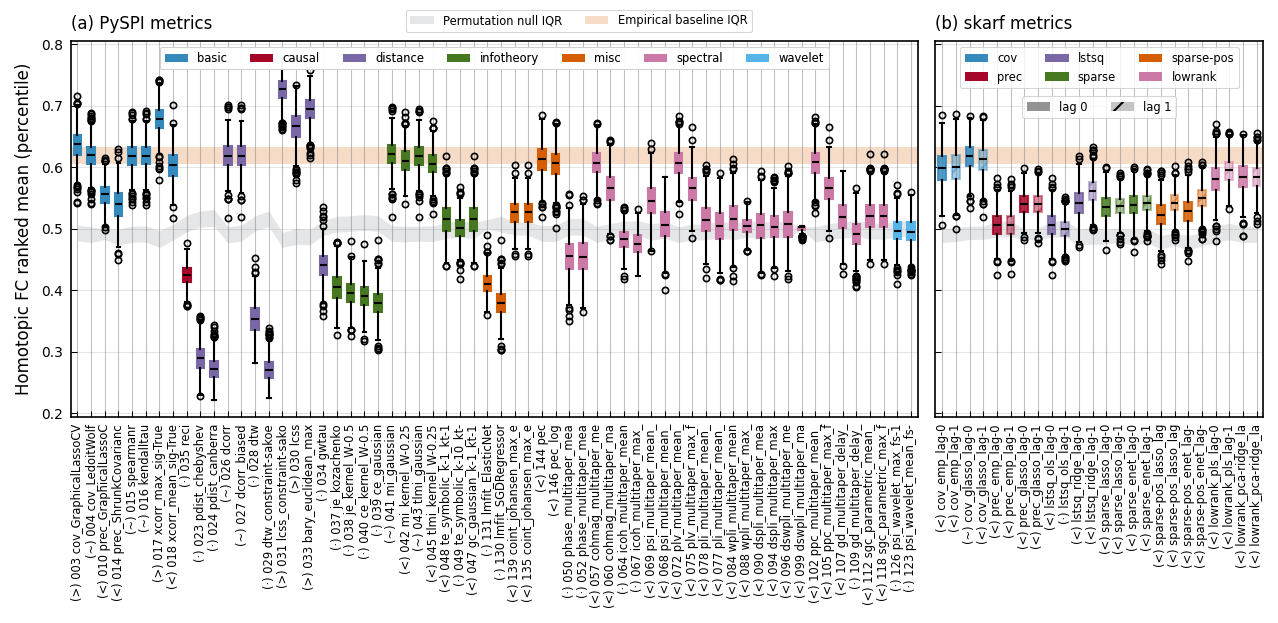

In [14]:
left_width = max(len(pyspi_funcs), 1)
right_width = max(len(skarf_func_order) * len(LAG_ORDER), 1)
fig, axes = plt.subplots(
    1,
    2,
    figsize=(3 * PLOTW, 0.95 * PLOTW),
    gridspec_kw={"width_ratios": [left_width, right_width]},
    sharey=True,
)

ax = axes[0]

null_handle = None
if pyspi_funcs:
    pyspi_positions = np.arange(len(pyspi_funcs), dtype=np.float64)
    pyspi_null_q25 = np.array([
        pyspi_null_df.loc[spi, "heterotopic_null_q25"] if spi in pyspi_null_df.index else np.nan
        for spi in pyspi_funcs
    ], dtype=np.float64)
    pyspi_null_q75 = np.array([
        pyspi_null_df.loc[spi, "heterotopic_null_q75"] if spi in pyspi_null_df.index else np.nan
        for spi in pyspi_funcs
    ], dtype=np.float64)

    null_handle = add_estimator_null_band(
        ax,
        pyspi_positions,
        pyspi_null_q25,
        pyspi_null_q75,
        PERM_NULL_BAND_COLOR,
        PERM_NULL_BAND_ALPHA,
        label="Permutation null IQR",
    )

emp_handle = add_iqr_band(
    ax,
    emp_cov_q25,
    emp_cov_q75,
    EMPIRICAL_COV_BAND_COLOR,
    EMPIRICAL_COV_BAND_ALPHA,
    label="Empirical baseline IQR",
)

if pyspi_funcs:
    pyspi_data = [
        pyspi_with_meta.loc[pyspi_with_meta["spi"] == spi, score_col].to_numpy(dtype=np.float64)
        for spi in pyspi_funcs
    ]
    pyspi_box = ax.boxplot(
        pyspi_data,
        positions=pyspi_positions,
        widths=0.55,
        patch_artist=True,
        medianprops={"color": "k"},
    )
    for spi, patch in zip(pyspi_funcs, pyspi_box["boxes"]):
        category = pyspi_func_to_category[spi]
        color = pyspi_category_colors.get(category, "#999999")
        patch.set_facecolor(color)
        patch.set_edgecolor(color)

    pyspi_labels = [pyspi_signif_labels.get(spi, spi[:20]) for spi in pyspi_funcs]
    ax.set_xticks(pyspi_positions)
    ax.set_xticklabels(pyspi_labels, rotation=90, fontsize="x-small")
else:
    ax.set_xticks([])

ax.set_title("(a) PySPI metrics", loc="left", fontsize="medium")
ax.set_ylabel("Homotopic FC ranked mean (percentile)", fontsize="medium")

ref_handles = [handle for handle in [null_handle, emp_handle] if handle is not None]
if ref_handles:
    ref_legend = ax.legend(
        handles=ref_handles,
        loc="upper center",
        bbox_to_anchor=(0.6, 1.1),
        ncol=len(ref_handles),
        fontsize="x-small",
    )
    ax.add_artist(ref_legend)

pyspi_cat_handles = [
    mpatches.Patch(facecolor=pyspi_category_colors[category], edgecolor="none", label=category)
    for category in pyspi_categories
]
if pyspi_cat_handles:
    cat_legend = ax.legend(
        handles=pyspi_cat_handles,
        loc="upper center",
        ncol=max(len(pyspi_cat_handles), 1),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)

ax = axes[1]
add_iqr_band(ax, emp_cov_q25, emp_cov_q75, EMPIRICAL_COV_BAND_COLOR, EMPIRICAL_COV_BAND_ALPHA)

if skarf_func_order:
    combo_positions = {}
    xtick_positions = []
    xtick_labels = []

    skarf_test_count = max(len(skarf_func_order) * len(LAG_ORDER), 1)

    for func_idx, func in enumerate(skarf_func_order):
        for lag_idx, lag in enumerate(LAG_ORDER):
            pos = func_idx * len(LAG_ORDER) + lag_idx
            combo_positions[(func, lag)] = pos
            xtick_positions.append(pos)

            vals = skarf_df.loc[
                (skarf_df["func"] == func) & (skarf_df["lag"] == lag),
                score_col,
            ].to_numpy(dtype=np.float64)

            null_vals = skarf_df.loc[
                (skarf_df["func"] == func) & (skarf_df["lag"] == lag),
                "heterotopic_null_mean",
            ].to_numpy(dtype=np.float64) if "heterotopic_null_mean" in skarf_df.columns else np.array([], dtype=np.float64)

            if len(null_vals) == 0:
                row = skarf_null_ref_df.loc[
                    (skarf_null_ref_df["func"] == func) & (skarf_null_ref_df["lag"] == lag),
                    "heterotopic_null_mean",
                ]
                if len(row) > 0:
                    null_vals = np.array([float(row.iloc[0])], dtype=np.float64)

            null_p = _safe_mwu_pvalue(vals, null_vals, alternative="greater")
            baseline_p = _safe_mwu_pvalue(vals, emp_cov_df, alternative="two-sided")
            base = f"{func_display_names.get(func, func)}_lag-{lag}"[:20]
            xtick_labels.append(
                format_label(
                    base,
                    vals[np.isfinite(vals)],
                    null_p,
                    baseline_p,
                    skarf_test_count,
                    emp_cov_median,
                )
            )

    skarf_null_positions = np.asarray(xtick_positions, dtype=np.float64)
    skarf_null_q25 = []
    skarf_null_q75 = []
    for func in skarf_func_order:
        for lag in LAG_ORDER:
            row = skarf_null_df.loc[(skarf_null_df["func"] == func) & (skarf_null_df["lag"] == lag)]
            if len(row) == 0:
                skarf_null_q25.append(np.nan)
                skarf_null_q75.append(np.nan)
            else:
                skarf_null_q25.append(float(row["heterotopic_null_q25"].iloc[0]))
                skarf_null_q75.append(float(row["heterotopic_null_q75"].iloc[0]))

    add_estimator_null_band(
        ax,
        skarf_null_positions,
        np.asarray(skarf_null_q25, dtype=np.float64),
        np.asarray(skarf_null_q75, dtype=np.float64),
        PERM_NULL_BAND_COLOR,
        PERM_NULL_BAND_ALPHA,
    )

    for lag in LAG_ORDER:
        lag_positions = np.array([combo_positions[(func, lag)] for func in skarf_func_order], dtype=np.float64)
        lag_data = []

        for func in skarf_func_order:
            vals = skarf_df.loc[
                (skarf_df["func"] == func) & (skarf_df["lag"] == lag),
                score_col,
            ].to_numpy(dtype=np.float64)
            lag_data.append(vals if len(vals) else np.array([np.nan]))

        box = ax.boxplot(
            lag_data,
            positions=lag_positions,
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "k"},
        )

        for func, patch in zip(skarf_func_order, box["boxes"]):
            category = func_category_map.get(func, "unknown")
            color = skarf_category_colors.get(category, "#999999")
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
            patch.set_alpha(LAG_STYLES[lag]["alpha"])
            patch.set_hatch(LAG_STYLES[lag]["hatch"])

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, rotation=90, fontsize="x-small")
else:
    ax.set_xticks([])

ax.set_title("(b) skarf metrics", loc="left", fontsize="medium")

skarf_cat_handles = [
    mpatches.Patch(facecolor=skarf_category_colors[category], edgecolor="none", label=category)
    for category in skarf_categories
]
lag_handles = [
    mpatches.Patch(facecolor="gray", alpha=LAG_STYLES[lag]["alpha"], hatch=LAG_STYLES[lag]["hatch"], label=f"lag {lag}")
    for lag in LAG_ORDER
]
if skarf_cat_handles:
    cat_legend = ax.legend(
        handles=skarf_cat_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=max(len(skarf_cat_handles) // 2, 1),
        fontsize="x-small",
    )
    ax.add_artist(cat_legend)
if lag_handles:
    ax.legend(
        handles=lag_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.87),
        ncol=len(lag_handles),
        fontsize="x-small",
    )

for axis in axes:
    axis.grid(alpha=0.2, axis="y")

plt.subplots_adjust(wspace=0.03)
plt.show()